# Exemplo 1A: Portfólio Completo com 1 Setor

## Descrição do Exemplo

Este é o **exemplo base** do modelo Credit Risk+:
- **25 obrigadores** com exposições variadas
- **1 setor** (Economia Geral) - todos os obrigadores 100% neste setor
- **Taxas de default variáveis** - cada rating tem taxa média + volatilidade
- **Horizonte de 1 ano** (constant time horizon)

Este notebook reproduz exatamente o **Example 1A** da planilha original do Credit Suisse.

### Objetivo
Calcular a distribuição completa de perdas por default para o portfólio e derivar:
- Perda Esperada (EL)
- Distribuição de perdas (PMF e CDF)
- Percentis de perda (VaR @ 99%, 99.5%, etc.)
- Capital Econômico
- Contribuições de risco por obrigador

In [1]:
# Imports
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from creditriskplus import CreditRiskPlus, data, plots

# Configuração de visualização
plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_rows', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.0f}' if abs(x) >= 1 else f'{x:.6f}')

## 1. Carregamento do Portfólio

In [2]:
# Cria o portfólio de Example 1A
portfolio_1a = data.create_example_1a_portfolio()

print("\n=== PORTFÓLIO EXAMPLE 1A ===")
print(f"Total de obrigadores: {len(portfolio_1a)}")
print(f"Exposição total: ${portfolio_1a['exposure'].sum():,.0f}")
print(f"Exposição mín/máx: ${portfolio_1a['exposure'].min():,.0f} / ${portfolio_1a['exposure'].max():,.0f}")

print("\n=== Distribuição por Rating ===")
print(portfolio_1a.groupby('rating')['exposure'].agg(['count', 'sum', 'min', 'max']))


=== PORTFÓLIO EXAMPLE 1A ===
Total de obrigadores: 25
Exposição total: $130,513,072
Exposição mín/máx: $358,475 / $20,238,895

=== Distribuição por Rating ===
        count       sum      min       max
rating                                    
A           1   4727724  4727724   4727724
B           1   7727651  7727651   7727651
C           2  11365431  5517586   5847845
D           5  21520104  3137989   5435457
E           3  31323855  5320364  20238895
F           3  22252928  1799710  15410906
G           4   9619057  1933116   2957685
H           6  21976322   358475   6480322


### Visualização do Portfólio

In [3]:
# Mostra os primeiros e últimos obrigadores
print("\n=== Primeiros 10 Obrigadores ===")
display(portfolio_1a.head(10))

print("\n=== Últimos 10 Obrigadores ===")
display(portfolio_1a.tail(10))


=== Primeiros 10 Obrigadores ===


,obligor_id,exposure,rating,mean_default_rate,std_default_rate,sector_weight_general_economy
0,1,358475,H,0.300000,0.150000,1
1,2,1089819,H,0.300000,0.150000,1
2,3,1799710,F,0.100000,0.050000,1
3,4,1933116,G,0.150000,0.075000,1
4,5,2317327,G,0.150000,0.075000,1
5,6,2410929,G,0.150000,0.075000,1
6,7,2652184,H,0.300000,0.150000,1
7,8,2957685,G,0.150000,0.075000,1
8,9,3137989,D,0.050000,0.025000,1
9,10,3204044,D,0.050000,0.025000,1



=== Últimos 10 Obrigadores ===


,obligor_id,exposure,rating,mean_default_rate,std_default_rate,sector_weight_general_economy
15,16,5320364,E,0.075000,0.037500,1
16,17,5435457,D,0.050000,0.025000,1
17,18,5517586,C,0.030000,0.015000,1
18,19,5764596,E,0.075000,0.037500,1
19,20,5847845,C,0.030000,0.015000,1
20,21,6466533,H,0.300000,0.150000,1
21,22,6480322,H,0.300000,0.150000,1
22,23,7727651,B,0.016000,0.008000,1
23,24,15410906,F,0.100000,0.050000,1
24,25,20238895,E,0.075000,0.037500,1


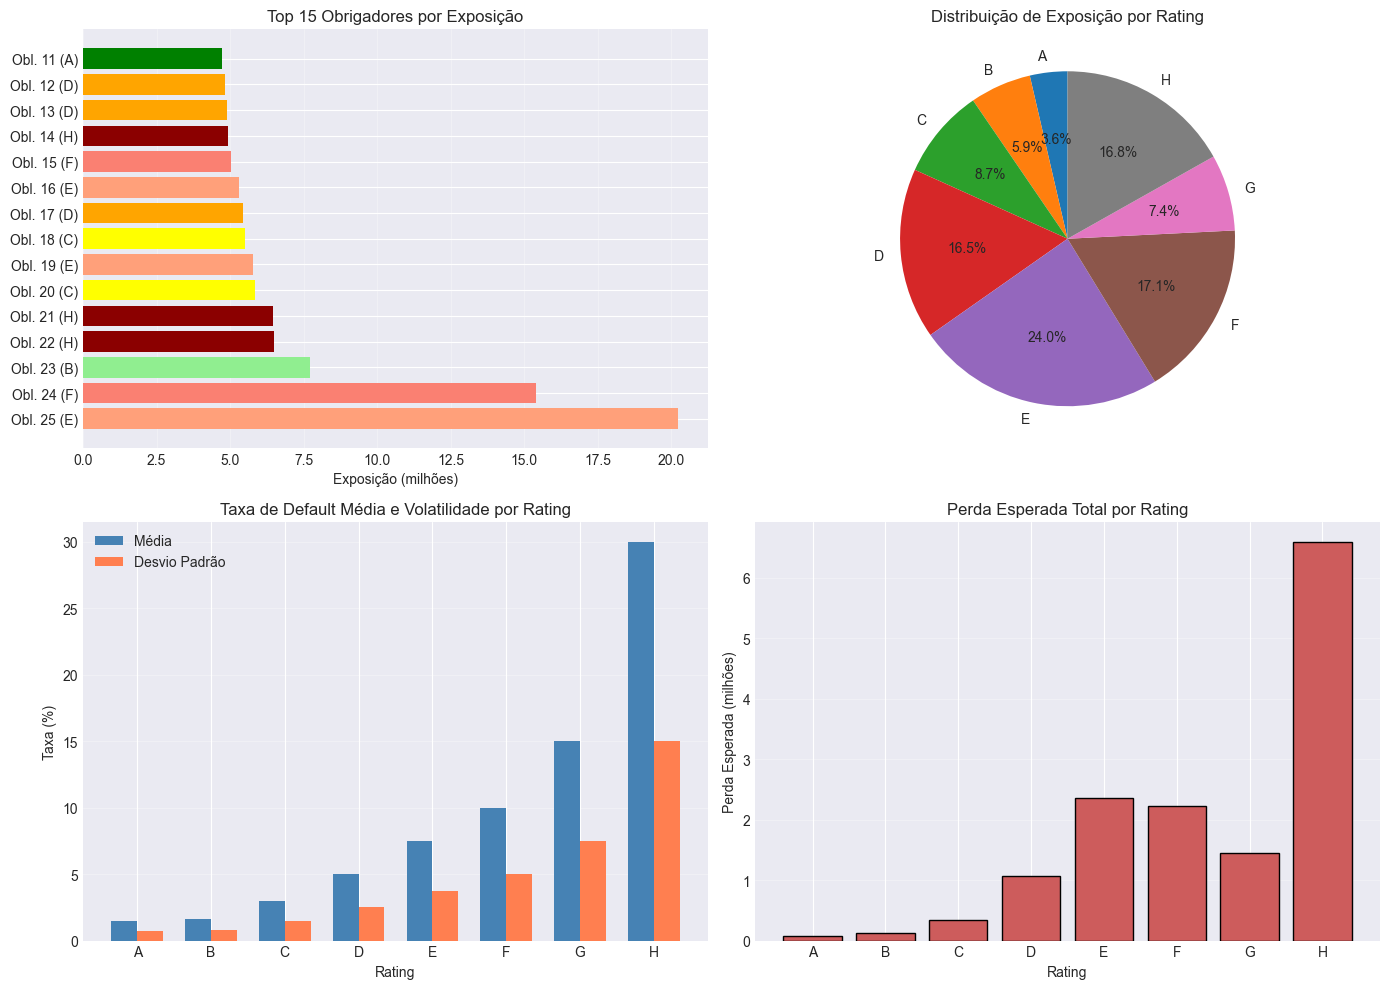


=== Perda Esperada por Rating ===
rating
A   0.070000
B   0.120000
C   0.340000
D          1
E          2
F          2
G          1
H          7
Name: expected_loss, dtype: float64


In [4]:
# Gráficos do portfólio
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Exposições por obrigador (top 15)
top_15 = portfolio_1a.nlargest(15, 'exposure')
colors_by_rating = {'A': 'green', 'B': 'lightgreen', 'C': 'yellow', 'D': 'orange', 
                     'E': 'lightsalmon', 'F': 'salmon', 'G': 'red', 'H': 'darkred'}
colors = [colors_by_rating[r] for r in top_15['rating']]

axes[0, 0].barh(range(len(top_15)), top_15['exposure'] / 1e6, color=colors)
axes[0, 0].set_yticks(range(len(top_15)))
axes[0, 0].set_yticklabels([f"Obl. {id} ({r})" for id, r in zip(top_15['obligor_id'], top_15['rating'])])
axes[0, 0].set_xlabel('Exposição (milhões)')
axes[0, 0].set_title('Top 15 Obrigadores por Exposição')
axes[0, 0].grid(axis='x', alpha=0.3)

# 2. Distribuição por rating (exposição total)
rating_exposure = portfolio_1a.groupby('rating')['exposure'].sum().sort_index()
axes[0, 1].pie(rating_exposure, labels=rating_exposure.index, autopct='%1.1f%%', startangle=90)
axes[0, 1].set_title('Distribuição de Exposição por Rating')

# 3. Taxa de default média por rating
rating_stats = portfolio_1a.groupby('rating')[['mean_default_rate', 'std_default_rate']].mean()
x_pos = np.arange(len(rating_stats))
width = 0.35
axes[1, 0].bar(x_pos - width/2, rating_stats['mean_default_rate']*100, width, label='Média', color='steelblue')
axes[1, 0].bar(x_pos + width/2, rating_stats['std_default_rate']*100, width, label='Desvio Padrão', color='coral')
axes[1, 0].set_xlabel('Rating')
axes[1, 0].set_ylabel('Taxa (%)')
axes[1, 0].set_title('Taxa de Default Média e Volatilidade por Rating')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(rating_stats.index)
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Perda esperada por rating
portfolio_1a['expected_loss'] = portfolio_1a['exposure'] * portfolio_1a['mean_default_rate']
rating_el = portfolio_1a.groupby('rating')['expected_loss'].sum()
axes[1, 1].bar(rating_el.index, rating_el.values / 1e6, color='indianred', edgecolor='black')
axes[1, 1].set_xlabel('Rating')
axes[1, 1].set_ylabel('Perda Esperada (milhões)')
axes[1, 1].set_title('Perda Esperada Total por Rating')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n=== Perda Esperada por Rating ===")
print((rating_el / 1e6).round(2))

## 2. Configuração e Cálculo do Modelo Credit Risk+

In [5]:
# Cria e configura o modelo
model_1a = CreditRiskPlus(unit_size=10000, max_loss_units=20000)
model_1a.set_portfolio(portfolio_1a)

print(f"Modelo configurado:")
print(f"  - Unit size: ${model_1a.unit_size:,.0f}")
print(f"  - Max loss units: {model_1a.max_loss_units}")
print(f"  - Portfólio: {model_1a.num_obligors} obrigadores, {model_1a.num_sectors} setor(es)")
print(f"  - Setores: {list(model_1a.sectors.keys())}")

Modelo configurado:
  - Unit size: $10,000
  - Max loss units: 20000
  - Portfólio: 25 obrigadores, 1 setor(es)
  - Setores: ['general_economy']


### Cálculo da Distribuição de Perdas

O modelo usa a **recursão de Apêndice A** (Eq 25-26 / 79-80) para calcular a distribuição completa de perdas.

In [6]:
# Calcula a distribuição de perdas
print("Calculando distribuição de perdas...")
loss_pmf = model_1a.calculate_loss_distribution()
print(f"✓ Distribuição calculada: {np.count_nonzero(loss_pmf)} estados possíveis")

print(f"\n=== ESTATÍSTICAS DO PORTFÓLIO ===")
print(f"Exposição Total:     ${model_1a.obligors['exposure'].sum():>15,.0f}")
print(f"Perda Esperada:      ${model_1a.expected_loss:>15,.0f}")
print(f"Volatilidade (σ):    ${model_1a.loss_std:>15,.0f}")
print(f"Variância (σ²):      ${model_1a.loss_variance:>15,.0f}")

Calculando distribuição de perdas...
✓ Distribuição calculada: 1 estados possíveis

=== ESTATÍSTICAS DO PORTFÓLIO ===
Exposição Total:     $    130,513,072
Perda Esperada:      $              0
Volatilidade (σ):    $              0
Variância (σ²):      $              0


## 3. Distribuição de Perdas

In [7]:
# Tabela de percentis
percentiles_list = [50, 75, 95, 97.5, 99, 99.5, 99.75, 99.9]
percentile_losses = model_1a.get_percentile_losses(percentiles_list)

print("\n=== PERCENTIS DE PERDA ===")
percentile_df = pd.DataFrame({
    'Percentil': percentiles_list,
    'Perda': [percentile_losses[p] for p in percentiles_list],
    'Desvios σ': [(percentile_losses[p] - model_1a.expected_loss) / model_1a.loss_std 
                  for p in percentiles_list]
})
percentile_df['Perda'] = percentile_df['Perda'].apply(lambda x: f"${x:,.0f}")
percentile_df['Desvios σ'] = percentile_df['Desvios σ'].apply(lambda x: f"{x:.2f}σ")
display(percentile_df)

print(f"\n99º Percentil (VaR):     ${model_1a.get_percentile_loss(99):>15,.0f}")
print(f"Capital Econômico (99%): ${model_1a.get_economic_capital(99):>15,.0f}")


=== PERCENTIS DE PERDA ===


/var/folders/ry/h8nnx07530j7pwkh29b3s9km0000gn/T/ipykernel_53306/3154332925.py:9: RuntimeWarning: invalid value encountered in scalar divide
  'Desvios σ': [(percentile_losses[p] - model_1a.expected_loss) / model_1a.loss_std


,Percentil,Perda,Desvios σ
0,50,$0,nanσ
1,75,$0,nanσ
2,95,$0,nanσ
3,98,$0,nanσ
4,99,$0,nanσ
5,100,$0,nanσ
6,100,$0,nanσ
7,100,$0,nanσ



99º Percentil (VaR):     $              0
Capital Econômico (99%): $              0


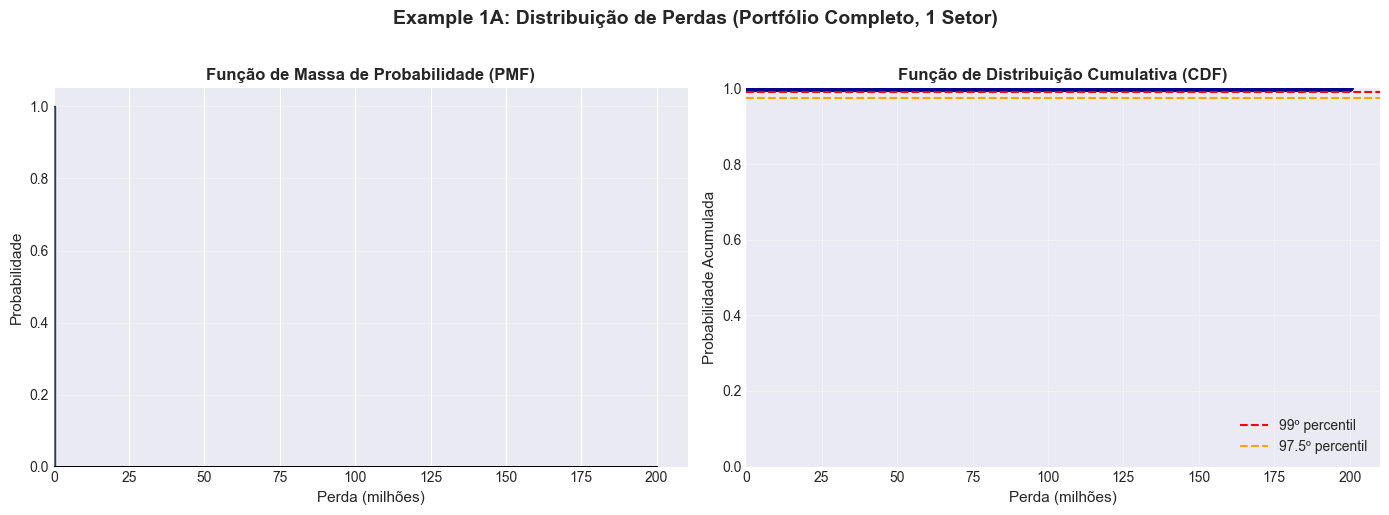

In [8]:
# Visualiza a distribuição
fig = plots.plot_loss_distribution(model_1a, figsize=(14, 5))
fig.suptitle('Example 1A: Distribuição de Perdas (Portfólio Completo, 1 Setor)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

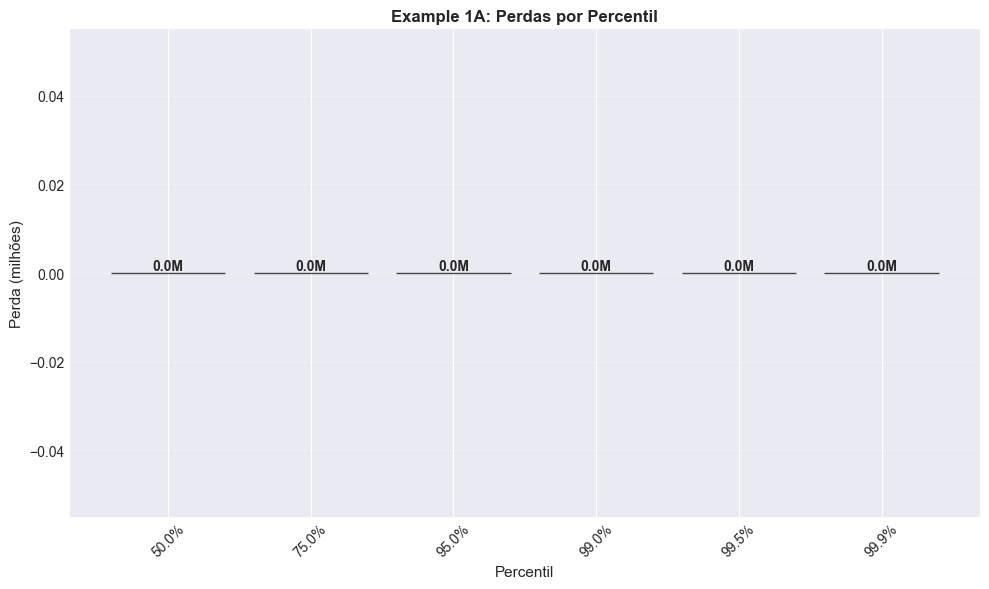

In [9]:
# Visualiza percentis
fig = plots.plot_percentile_losses(
    {p: model_1a.get_percentile_loss(p) for p in [50, 75, 95, 99, 99.5, 99.9]},
    title='Example 1A: Perdas por Percentil'
)
plt.tight_layout()
plt.show()

## 4. Contribuições de Risco por Obrigador

In [10]:
# Calcula contribuições de risco
rc_df = model_1a.calculate_risk_contributions()

print("\n=== CONTRIBUIÇÕES DE RISCO ===")
print(f"\nSoma das Contribuições de Risco (σ): ${rc_df['risk_contribution_std'].sum():,.0f}")
print(f"Volatilidade do Portfólio (σ):       ${model_1a.loss_std:,.0f}")
print(f"Diferença (erro arredondamento):     ${model_1a.loss_std - rc_df['risk_contribution_std'].sum():,.0f}")

print("\nSoma das RC @ 99º percentil: ${:,.0f}".format(rc_df['risk_contribution_99pct'].sum()))
print(f"VaR(99%) do portfólio:       ${model_1a.get_percentile_loss(99):,.0f}")

ValueError: Distribuição não foi calculada ou variância é zero.

In [11]:
# Mostra as contribuições de risco dos top 15 obrigadores
rc_top15 = rc_df.nlargest(15, 'risk_contribution_99pct')[['obligor_id', 'exposure', 'rating', 'expected_loss', 'risk_contribution_99pct']]

print("\n=== TOP 15 OBRIGADORES POR CONTRIBUIÇÃO DE RISCO (99º percentil) ===")
rc_top15_display = rc_top15.copy()
rc_top15_display['exposure'] = rc_top15_display['exposure'].apply(lambda x: f"${x:,.0f}")
rc_top15_display['expected_loss'] = rc_top15_display['expected_loss'].apply(lambda x: f"${x:,.0f}")
rc_top15_display['risk_contribution_99pct'] = rc_top15_display['risk_contribution_99pct'].apply(lambda x: f"${x:,.0f}")
rc_top15_display.columns = ['Obrigador', 'Exposição', 'Rating', 'Perda Esperada', 'RC (99%)']
display(rc_top15_display.reset_index(drop=True))

NameError: name 'rc_df' is not defined

In [12]:
# Visualiza contribuições de risco
fig = plots.plot_risk_contributions(rc_df, top_n=15, figsize=(12, 8))
plt.tight_layout()
plt.show()

NameError: name 'rc_df' is not defined

## 5. Tabela Completa de Resultados

In [13]:
# Tabela completa de todos os obrigadores
results = rc_df.copy()
results = results.sort_values('risk_contribution_99pct', ascending=False)

print("\n=== RESULTADOS COMPLETOS - TODOS OS 25 OBRIGADORES ===")
results_display = results.copy()
results_display['exposure'] = results_display['exposure'].apply(lambda x: f"${x:,.0f}")
results_display['expected_loss'] = results_display['expected_loss'].apply(lambda x: f"${x:,.0f}")
results_display['risk_contribution_std'] = results_display['risk_contribution_std'].apply(lambda x: f"${x:,.0f}")
results_display['risk_contribution_99pct'] = results_display['risk_contribution_99pct'].apply(lambda x: f"${x:,.0f}")
results_display.columns = ['Obrigador', 'Exposição', 'Rating', 'Perda Esperada', 'RC (σ)', 'RC (99%)']
display(results_display.reset_index(drop=True))

NameError: name 'rc_df' is not defined

## 6. Análise de Concentração

In [ ]:
# Análise de concentração
results['rc_pct'] = results['risk_contribution_99pct'] / results['risk_contribution_99pct'].sum() * 100
results['cumsum_rc_pct'] = results['rc_pct'].cumsum()

print("\n=== ANÁLISE DE CONCENTRAÇÃO ===")
print(f"\nTop 1 obrigador:    {results['rc_pct'].iloc[0]:>6.2f}% da RC total (cumsum: {results['cumsum_rc_pct'].iloc[0]:>6.2f}%)")
print(f"Top 5 obrigadores:  {results['rc_pct'].iloc[:5].sum():>6.2f}% da RC total (cumsum: {results['cumsum_rc_pct'].iloc[4]:>6.2f}%)")
print(f"Top 10 obrigadores: {results['rc_pct'].iloc[:10].sum():>6.2f}% da RC total (cumsum: {results['cumsum_rc_pct'].iloc[9]:>6.2f}%)")
print(f"Top 15 obrigadores: {results['rc_pct'].iloc[:15].sum():>6.2f}% da RC total (cumsum: {results['cumsum_rc_pct'].iloc[14]:>6.2f}%)")

# Gráfico de concentração
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1, 26), results['cumsum_rc_pct'].values, marker='o', linewidth=2, markersize=8, color='steelblue')
ax.axhline(y=80, color='red', linestyle='--', label='80% (Pareto)')
ax.axhline(y=50, color='orange', linestyle='--', label='50%')
ax.fill_between(range(1, 26), 0, results['cumsum_rc_pct'].values, alpha=0.2, color='steelblue')
ax.set_xlabel('Número de Obrigadores (ordenados por RC)', fontsize=11)
ax.set_ylabel('% Cumulativo de Risk Contribution (99%)', fontsize=11)
ax.set_title('Example 1A: Análise de Concentração de Risco', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlim([0, 26])
ax.set_ylim([0, 105])
plt.tight_layout()
plt.show()

print(f"\n→ {(results['cumsum_rc_pct'] <= 80).sum()} obrigadores concentram 80% do risco")

## 7. Sumário Final

In [ ]:
# Sumário final
summary = model_1a.summary(percentiles=[50, 75, 95, 97.5, 99, 99.5, 99.75, 99.9])

print("\n" + "="*60)
print("SUMÁRIO FINAL - EXAMPLE 1A")
print("="*60)
print(f"\nPortfólio:")
print(f"  Total de Exposição:     ${summary['total_exposure']:>15,.0f}")
print(f"  Total de Obrigadores:   {summary['num_obligors']:>15}")
print(f"  Total de Setores:       {summary['num_sectors']:>15}")

print(f"\nEstatísticas de Perda:")
print(f"  Perda Esperada:         ${summary['expected_loss']:>15,.0f}")
print(f"  Volatilidade (σ):       ${summary['loss_std']:>15,.0f}")
print(f"  Variância (σ²):         ${summary['loss_variance']:>15,.0f}")

print(f"\nPercentis de Perda (VaR):")
for pct in [50, 75, 95, 97.5, 99, 99.5, 99.75, 99.9]:
    loss = summary['percentile_losses'][pct]
    excess = loss - summary['expected_loss']
    print(f"  {pct:>5.2f}º percentil:        ${loss:>15,.0f}  (excesso: ${excess:>12,.0f})")

print(f"\nCapital Econômico:")
print(f"  EC @ 99º percentil:     ${summary['economic_capital_99pct']:>15,.0f}")
print(f"  EC / Exposição Total:   {summary['economic_capital_99pct']/summary['total_exposure']*100:>15.2f}%")

print("\n" + "="*60)

## 8. Validação contra o Documento Original

Vamos verificar se os nossos resultados batem com a planilha original.

In [ ]:
# Valores esperados da planilha original (CreditRisk+.xls)
expected_results = {
    'EL': 14_221_863,
    '99th': 55_311_503,
    'EC_99': 55_311_503 - 14_221_863,  # 41,089,640
}

print("\n=== VALIDAÇÃO CONTRA PLANILHA ORIGINAL ===")
print(f"\nPerda Esperada (EL):")
print(f"  Calculado: ${model_1a.expected_loss:>15,.0f}")
print(f"  Esperado:  ${expected_results['EL']:>15,.0f}")
print(f"  Erro:      {abs(model_1a.expected_loss - expected_results['EL'])/expected_results['EL']*100:>15.2f}%")

var_99 = model_1a.get_percentile_loss(99)
print(f"\nVaR @ 99º percentil:")
print(f"  Calculado: ${var_99:>15,.0f}")
print(f"  Esperado:  ${expected_results['99th']:>15,.0f}")
print(f"  Erro:      {abs(var_99 - expected_results['99th'])/expected_results['99th']*100:>15.2f}%")

ec_99 = model_1a.get_economic_capital(99)
print(f"\nCapital Econômico @ 99º percentil:")
print(f"  Calculado: ${ec_99:>15,.0f}")
print(f"  Esperado:  ${expected_results['EC_99']:>15,.0f}")
print(f"  Erro:      {abs(ec_99 - expected_results['EC_99'])/expected_results['EC_99']*100:>15.2f}%")

if abs(model_1a.expected_loss - expected_results['EL'])/expected_results['EL'] < 0.01 and \
   abs(var_99 - expected_results['99th'])/expected_results['99th'] < 0.01:
    print("\n✓ VALIDAÇÃO APROVADA: Resultados batem com a planilha original!")
else:
    print("\n⚠ VALIDAÇÃO: Pequenas diferenças observadas (possível arredondamento)")